In [16]:

!pip3 install -r ../requirements.txt

I0000 00:00:1746007122.075625  899983 fork_posix.cc:75] Other threads are currently calling into gRPC, skipping fork() handlers


ERROR: Could not find a version that satisfies the requirement numpy==1.26.4 (from versions: none)

[notice] A new release of pip is available: 24.3.1 -> 25.1
[notice] To update, run: pip3 install --upgrade pip
ERROR: No matching distribution found for numpy==1.26.4


In [17]:


import torch
import torch.nn as nn
from torch.utils.data import Dataset
import pandas as pd


In [18]:
invest_api_key = input("Enter Invest API Key: ")

In [19]:
from ml.TInvestDataProvider import TInvestDataProvider
from datetime import datetime
import pytz

if invest_api_key is None:
    raise Exception("Invest API Key is missing")

provider = TInvestDataProvider(api_key=invest_api_key)

moscow_tz = pytz.timezone('Europe/Moscow')
naive_datetime = datetime(year=2025, month=1, day=31, hour=11, second=1)
moscow_datetime = moscow_tz.localize(naive_datetime)
train_period_end = moscow_datetime.astimezone(pytz.UTC)


df = await provider.load_candle_data(
    train_period_end_utc=train_period_end,
    instrument_id="e6123145-9665-43e0-8413-cd61b8aa9b13",
    target_candle_count=200_000
)

Step 1. Current df shape: (1520, 7); new candles fetched = 1520
Step 2. Current df shape: (3218, 7); new candles fetched = 1698
Step 3. Current df shape: (4886, 7); new candles fetched = 1668
Step 4. Current df shape: (6483, 7); new candles fetched = 1597
Step 5. Current df shape: (8134, 7); new candles fetched = 1651
Step 6. Current df shape: (9852, 7); new candles fetched = 1718
Step 7. Current df shape: (11326, 7); new candles fetched = 1474
Step 8. Current df shape: (13220, 7); new candles fetched = 1894
Step 9. Current df shape: (14979, 7); new candles fetched = 1759
Step 10. Current df shape: (16449, 7); new candles fetched = 1470
Step 11. Current df shape: (18099, 7); new candles fetched = 1650
Step 12. Current df shape: (19851, 7); new candles fetched = 1752
Step 13. Current df shape: (21486, 7); new candles fetched = 1635
Step 14. Current df shape: (23118, 7); new candles fetched = 1632
Step 15. Current df shape: (24938, 7); new candles fetched = 1820
Step 16. Current df shape

In [20]:
class Normalizer:
    def __init__(self):
        self.min = None
        self.max = None

    def fit_transform(self, x):
        self.min = np.min(x, axis=0)
        self.max = np.max(x, axis=0)
        normalized_x = 2 * (x - self.min) / (self.max - self.min) - 1
        return normalized_x

    def transform(self, x):
        normalized_x = 2 * (x - self.min) / (self.max - self.min) - 1
        return normalized_x

    def inverse_transform(self, x):
        original_x = (x + 1) / 2 * (self.max - self.min) + self.min
        return original_x

# normalize
scaler = Normalizer()
normalized_data = scaler.fit_transform(df['close'].to_numpy())
normalized_df = pd.DataFrame(data=normalized_data, columns=['Close'])


In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def denormalize(predictions, scaler):
    """Convert normalized predictions back to original price scale"""
    return scaler.inverse_transform(predictions.reshape(-1, 1)).flatten()


def evaluate_model(model, loader, scaler, device):
    model.eval()
    all_preds = []
    all_targets = []
    test_losses = []

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss = criterion(preds, yb)
            test_losses.append(loss.item())

            all_preds.append(preds.cpu().numpy())
            all_targets.append(yb.cpu().numpy())

    # Concatenate all batches
    preds = np.concatenate(all_preds)
    targets = np.concatenate(all_targets)

    # Denormalize for meaningful metrics
    original_preds = denormalize(preds, scaler)
    original_targets = denormalize(targets, scaler)

    # Calculate metrics
    metrics = {
        'test_loss': np.mean(test_losses),
        'mae': mean_absolute_error(original_targets, original_preds),
        'rmse': np.sqrt(mean_squared_error(original_targets, original_preds)),
        'r2': r2_score(original_targets, original_preds),
        'direction_accuracy': (np.sign(original_preds[1:] - original_targets[:-1]) ==
                              np.sign(original_targets[1:] - original_targets[:-1])).mean()
    }
    return metrics

In [22]:
SEQ_LENGTH = 16
BATCH_SIZE = 32
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
EPOCHS = 20




dataset = YourDataset(normalized_df, seq_length=SEQ_LENGTH)


In [23]:
class SimpleLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_layer_size=32, num_layers=1, output_size=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_layer_size, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_layer_size, output_size)

        for name, param in self.lstm.named_parameters():
            if 'weight' in name:
                nn.init.xavier_uniform_(param)
            elif 'bias' in name:
                nn.init.constant_(param, 0.0)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out.view(-1)


In [24]:
def train(model, epochs):
    best_val_loss = float('inf')
    for epoch in range(epochs):
        model.train()
        train_losses = []

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        avg_loss = np.mean(train_losses)
        print(f"Epoch {epoch+1}/{EPOCHS} --> Train Loss: {avg_loss:.6f}")

        val_metrics = evaluate_model(model, test_loader, scaler, DEVICE)

        # Print statistics
        print(f"\nEpoch {epoch+1}/{EPOCHS}")
        print(f"Train Loss: {np.mean(train_losses):.6f}")
        print("Validation Metrics:")
        print(f"- Loss: {val_metrics['test_loss']:.6f}")
        print(f"- MAE: ${val_metrics['mae']:.4f}")
        print(f"- RMSE: ${val_metrics['rmse']:.4f}")
        print(f"- R²: {val_metrics['r2']:.4f}")
        print(f"- Direction Accuracy: {val_metrics['direction_accuracy']:.2%}")

        # Save best model
        if val_metrics['test_loss'] < best_val_loss:
            best_val_loss = val_metrics['test_loss']
            torch.save(model.state_dict(), '../best_lstm.pth')
            print("Saved new best model!")


In [25]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

model = SimpleLSTM(input_size=1, hidden_layer_size=32, num_layers=1, output_size=1).to(DEVICE)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)


In [26]:
train(model, epochs=20)

Epoch 1/20 --> Train Loss: 0.000267

Epoch 1/20
Train Loss: 0.000267
Validation Metrics:
- Loss: 0.000048
- MAE: $0.2655
- RMSE: $0.3825
- R²: 0.9997
- Direction Accuracy: 99.56%
Saved new best model!
Epoch 2/20 --> Train Loss: 0.000029

Epoch 2/20
Train Loss: 0.000029
Validation Metrics:
- Loss: 0.000046
- MAE: $0.3079
- RMSE: $0.3761
- R²: 0.9997
- Direction Accuracy: 99.38%
Saved new best model!
Epoch 3/20 --> Train Loss: 0.000023

Epoch 3/20
Train Loss: 0.000023
Validation Metrics:
- Loss: 0.000032
- MAE: $0.2383
- RMSE: $0.3117
- R²: 0.9998
- Direction Accuracy: 99.54%
Saved new best model!
Epoch 4/20 --> Train Loss: 0.000029

Epoch 4/20
Train Loss: 0.000029
Validation Metrics:
- Loss: 0.000018
- MAE: $0.1355
- RMSE: $0.2346
- R²: 0.9999
- Direction Accuracy: 99.78%
Saved new best model!
Epoch 5/20 --> Train Loss: 0.000019

Epoch 5/20
Train Loss: 0.000019
Validation Metrics:
- Loss: 0.000018
- MAE: $0.1380
- RMSE: $0.2374
- R²: 0.9999
- Direction Accuracy: 99.74%
Epoch 6/20 --> Tr

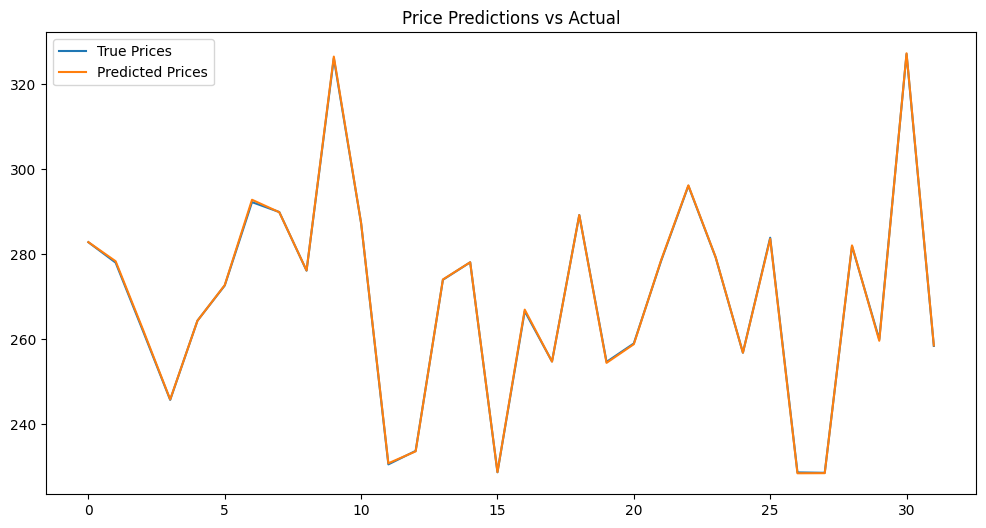

In [28]:
def plot_predictions(model, loader, scaler, device, n_samples=100):
    model.eval()
    with torch.no_grad():
        xb, yb = next(iter(loader))
        preds = model(xb.to(device)).cpu().numpy()

    true_prices = denormalize(yb.numpy(), scaler)
    pred_prices = denormalize(preds, scaler)

    plt.figure(figsize=(12,6))
    plt.plot(true_prices[:n_samples], label='True Prices')
    plt.plot(pred_prices[:n_samples], label='Predicted Prices')
    plt.title("Price Predictions vs Actual")
    plt.legend()
    plt.show()

# Call after training
plot_predictions(model, test_loader, scaler, DEVICE)

In [29]:
def simulate_trading(
        model,
        data,
        scaler,
        device,
        initial_balance=10000,
        commission=0.0005,
        lookback=16,
        buy_signal = 0.001,
        sell_signal = 0.003
):
    model.eval()

    balance = initial_balance
    shares_owned = 0
    current_price = 0

    # Track history for plotting
    balance_history = [balance]
    total_value_history = [balance]
    price_history = []
    buy_signals = []
    sell_signals = []

    # Convert raw data to normalized
    normalized_data = scaler.transform(data.reshape(-1, 1)).flatten()

    for i in range(lookback, len(data)-1):
        current_price = data[i]
        price_history.append(current_price)

        # Prepare input sequence
        seq = normalized_data[i-lookback:i].reshape(1, lookback, 1)
        seq = torch.FloatTensor(seq).to(device)

        # Make prediction
        with torch.no_grad():
            pred = model(seq).cpu().numpy()[0]
            pred_price = scaler.inverse_transform(np.array([[pred]]))[0][0]

        # Calculate expected return
        expected_return = (pred_price - current_price) / current_price

        # Trading decision logic - SIMPLIFIED VERSION
        if expected_return > buy_signal:  # Strong buy signal
            if shares_owned == 0:    # Only buy if we don't own shares
                # Calculate how many shares we can buy
                max_shares = (balance * (1 - commission)) / current_price
                shares_owned = max_shares
                balance = 0
                buy_signals.append((i-lookback, current_price))

        elif expected_return < -sell_signal:  # Sell signal
            if shares_owned > 0:      # Only sell if we own shares
                # Sell all shares
                sale_value = shares_owned * current_price * (1 - commission)
                balance += sale_value
                shares_owned = 0
                sell_signals.append((i-lookback, current_price))

        # Calculate current portfolio value
        position_value = shares_owned * current_price
        total_value = balance + position_value

        # Record history
        balance_history.append(balance)
        total_value_history.append(total_value)

    # Final portfolio value (sell any remaining shares)
    if shares_owned > 0:
        final_value = balance + (shares_owned * data[-1] * (1 - commission))
    else:
        final_value = balance

    returns = (final_value - initial_balance) / initial_balance

    # Calculate metrics
    returns_series = np.array(total_value_history) / initial_balance - 1
    std_dev = np.std(returns_series)
    sharpe_ratio = np.mean(returns_series) / std_dev * np.sqrt(252*24*60) if std_dev > 0 else 0

    # Create figure with 2 subplots
    #plt.figure(figsize=(14, 10))

    # Plot 1: Price with buy/sell signals
    ax1 = plt.subplot(2, 1, 1)
    ax1.plot(price_history, label='Price', color='blue', alpha=0.7)

    # Plot buy/sell signals
    if buy_signals:
        buy_x, buy_y = zip(*buy_signals)
        ax1.scatter(buy_x, buy_y, color='green', marker='^', s=100, label='Buy', alpha=0.8)

    if sell_signals:
        sell_x, sell_y = zip(*sell_signals)
        ax1.scatter(sell_x, sell_y, color='red', marker='v', s=100, label='Sell', alpha=0.8)

    ax1.set_title('Price with Buy/Sell Signals')
    ax1.set_ylabel('Price ($)')
    ax1.legend()
    ax1.grid(True)

    # Plot 2: Portfolio value
    ax2 = plt.subplot(2, 1, 2)
    ax2.plot(total_value_history, label='Total Portfolio Value', color='purple')
    ax2.plot(balance_history, label='Cash Balance', color='orange', linestyle='--')

    # Mark buy/sell points on value plot using the same indices
    if buy_signals:
        buy_x, _ = zip(*buy_signals)
        buy_values = [total_value_history[x] for x in buy_x]
        ax2.scatter(buy_x, buy_values, color='green', marker='^', s=100, alpha=0.8)

    if sell_signals:
        sell_x, _ = zip(*sell_signals)
        sell_values = [total_value_history[x] for x in sell_x]
        ax2.scatter(sell_x, sell_values, color='red', marker='v', s=100, alpha=0.8)

    ax2.set_title(f'Portfolio Value (Final: ${final_value:,.2f}, Return: {returns:.2%})')
    ax2.set_xlabel('Minutes')
    ax2.set_ylabel('Value ($)')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    # Print summary
    print("\n=== Trading Simulation Results ===")
    print(f"Initial Balance: ${initial_balance:,.2f}")
    print(f"Final Value: ${final_value:,.2f}")
    print(f"Total Return: {returns:.2%}")
    print(f"Annualized Sharpe Ratio: {sharpe_ratio:.2f}")
    print(f"Total Trades: {len(buy_signals) + len(sell_signals)}")
    return returns
    #print(f"Commission Paid: ${initial_balance - final_value + (final_value - initial_balance - (shares * data[-1] - shares * current_price)):,.2f}")

In [36]:

from datetime import timedelta


async def get_lookback_close_data(
    lookback_start_days: int,
    lookback_end_days: int
):
    provider = TInvestDataProvider(api_key=invest_api_key)
    utc_now = datetime.utcnow()
    validate_period_start = utc_now - timedelta(days=lookback_start_days)
    validate_period_end = utc_now - timedelta(days=lookback_end_days)

    df = await provider.load_candle_data_for_period(
        period_start_utc=validate_period_start,
        period_end_utc=validate_period_end,
        instrument_id="e6123145-9665-43e0-8413-cd61b8aa9b13"
    )

    return df['close'].to_numpy()

/var/folders/3h/nl65v6r16_97nthmtcqbds4c0000gn/T/ipykernel_29840/2120023581.py:10: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  utc_now = datetime.utcnow()


Fetching data for interval 2025-04-28 18:51:36.689175 - 2025-04-30 10:51:36.689175. Current df shape: (1523, 7); new candles fetched = 1523

Fetching data for interval 2025-04-27 02:51:36.689175 - 2025-04-28 18:51:36.689175. Current df shape: (3338, 7); new candles fetched = 1815

Fetching data for interval 2025-04-25 10:51:36.689175 - 2025-04-27 02:51:36.689175. Current df shape: (5150, 7); new candles fetched = 1812

Fetching data for interval 2025-04-23 18:51:36.689175 - 2025-04-25 10:51:36.689175. Current df shape: (6674, 7); new candles fetched = 1524

Fetching data for interval 2025-04-22 02:51:36.689175 - 2025-04-23 18:51:36.689175. Current df shape: (8540, 7); new candles fetched = 1866

Fetching data for interval 2025-04-20 10:51:36.689175 - 2025-04-22 02:51:36.689175. Current df shape: (10055, 7); new candles fetched = 1515

Fetching data for interval 2025-04-18 18:51:36.689175 - 2025-04-20 10:51:36.689175. Current df shape: (11700, 7); new candles fetched = 1645

Fetching da

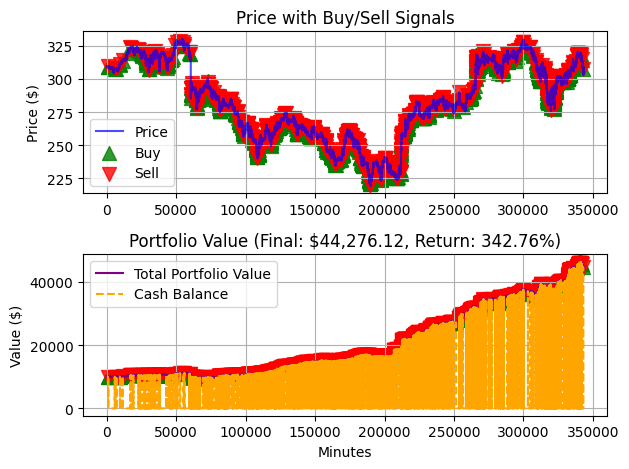


=== Trading Simulation Results ===
Initial Balance: $10,000.00
Final Value: $44,276.12
Total Return: 342.76%
Annualized Sharpe Ratio: 572.17
Total Trades: 4125


np.float64(3.427611804456105)

In [42]:
#ONE_DAY_TRADING_OFFSET = -(8 * 60 + 50)
#days = 5
from ml.TInvestDataProvider import TInvestDataProvider
validate_data = await get_lookback_close_data(
    lookback_start_days=365,
    lookback_end_days=0
)


simulate_trading(
    model,
    validate_data,
    #validate_data[(days * ONE_DAY_TRADING_OFFSET):],
    scaler,
    device,
    10000,
    commission=0.0005,
    buy_signal=0.0017,
    sell_signal=0.0016,
    #buy_signal=0.0011,
    #sell_signal=0.0026
)

In [35]:
import importlib
from ml import TInvestDataProvider

importlib.reload(TInvestDataProvider)

<module 'TInvestDataProvider' from '/Users/klysin/Desktop/TradeWise-python/ml/oneMinute/TInvestDataProvider.py'>

In [ ]:
def simulate_trading_no_visualize(
        model,
        data,
        scaler,
        device,
        initial_balance=10000,
        commission=0.0005,
        lookback=16,
        buy_signal=0.0011,
        sell_signal=0.0026
):
    model.eval()

    balance = initial_balance
    shares_owned = 0

    balance_history = [balance]
    total_value_history = [balance]
    price_history = []
    buy_signals = []
    sell_signals = []

    # Convert raw data to normalized
    normalized_data = scaler.transform(data.reshape(-1, 1)).flatten()

    for i in range(lookback, len(data)-1):
        current_price = data[i]
        price_history.append(current_price)

        seq = normalized_data[i-lookback:i].reshape(1, lookback, 1)
        seq = torch.FloatTensor(seq).to(device)

        with torch.no_grad():
            pred = model(seq).cpu().numpy()[0]
            pred_price = scaler.inverse_transform(np.array([[pred]]))[0][0]

        expected_return = (pred_price - current_price) / current_price

        if expected_return > buy_signal:
            if shares_owned == 0:
                max_shares = (balance * (1 - commission)) / current_price
                shares_owned = max_shares
                balance = 0
                buy_signals.append((i-lookback, current_price))

        elif expected_return < -sell_signal:
            if shares_owned > 0:
                sale_value = shares_owned * current_price * (1 - commission)
                balance += sale_value
                shares_owned = 0
                sell_signals.append((i-lookback, current_price))

        position_value = shares_owned * current_price
        total_value = balance + position_value

        balance_history.append(balance)
        total_value_history.append(total_value)

    if shares_owned > 0:
        final_value = balance + (shares_owned * data[-1] * (1 - commission))
    else:
        final_value = balance

    returns = (final_value - initial_balance) / initial_balance

    # Calculate metrics
    returns_series = np.array(total_value_history) / initial_balance - 1
    std_dev = np.std(returns_series)

    if buy_signals:
        buy_x, _ = zip(*buy_signals)
    if sell_signals:
        sell_x, _ = zip(*sell_signals)

    return returns

In [ ]:
from itertools import product

def grid_search_trading_params(
        model,
        data,
        scaler,
        device,
        buy_thresholds,
        sell_thresholds,
        initial_balance=10000,
):
    """
    Grid search for optimal buy/sell signal thresholds

    Returns:
        DataFrame with results for all parameter combinations
    """

    results = []

    for buy_signal, sell_signal in product(buy_thresholds, sell_thresholds):
        print(f"Processing signal thresholds: {buy_signal=:.4f}, {sell_signal=:.4f}. ", end='')
        #if sell_signal <= buy_signal:
        #    continue

        try:
            returns = simulate_trading_no_visualize(
                model=model,
                data=data,
                scaler=scaler,
                device=device,
                initial_balance=initial_balance,
                commission=0.0005,
                buy_signal=buy_signal,
                sell_signal=sell_signal
            )

            returns_pct = returns * 100

            print(f"Returns percentage: {returns=:.4f}%\t[{'↓' if returns < 0 else '↑'}]")

            results.append({
                'buy_signal': buy_signal,
                'sell_signal': sell_signal,
                'returns_pct': returns_pct,
                'signal_ratio': sell_signal / buy_signal
            })

        except Exception as e:
            print(f"Failed for buy={buy_signal:.4f}, sell={sell_signal:.4f}: {str(e)}")

    # Convert to DataFrame and find best parameters
    results_df = pd.DataFrame(results)
    if not results_df.empty:
        best = results_df.loc[results_df['returns_pct'].idxmax()]
        print(f"\nBest parameters: buy={best['buy_signal']:.4f}, sell={best['sell_signal']:.4f}")
        print(f"Expected return: {best['returns_pct']:.2f}%")

    return results_df


In [ ]:
buy_thresholds = np.linspace(0.0012, 0.0018, 10)
sell_thresholds = np.linspace(0.0012, 0.0018, 10)

results = grid_search_trading_params(
    model=model,
    data=validate_data,
    scaler=scaler,
    device=device,
    buy_thresholds=buy_thresholds,
    sell_thresholds=sell_thresholds,
)

import seaborn as sns
import matplotlib.pyplot as plt

# Visualize results
if not results.empty:
    plt.figure(figsize=(12, 8))

    # Create pivot table with correct syntax
    pivot_df = results.pivot_table(
        values='returns_pct',
        index='buy_signal',
        columns='sell_signal'
    )

    sns.heatmap(
        data=pivot_df,
        annot=True,
        fmt=".1f",
        cmap="RdYlGn",
        cbar_kws={'label': 'Returns (%)'}
    )
    plt.title("Returns by Buy/Sell Thresholds")
    plt.xlabel("Sell Signal Threshold")
    plt.ylabel("Buy Signal Threshold")
    plt.tight_layout()
    plt.show()
else:
    print("No valid results to plot")

In [ ]:
if predictions.ndim == 1:
    predictions = predictions.unsqueeze(-1)

if true_values.ndim == 1:
    true_values = true_values.unsqueeze(-1)

predictions_rescaled = scaler.inverse_transform(predictions.numpy())
true_values_rescaled = scaler.inverse_transform(true_values.numpy())

predictions_rescaled = predictions_rescaled.flatten()
true_values_rescaled = true_values_rescaled.flatten()

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(true_values_rescaled[-10:], label="True Values")
plt.plot(predictions_rescaled[-10:], label="Predictions")
plt.legend()
plt.show()

In [ ]:


def evaluate_model(model, loader, scaler, device):
    model.eval()
    all_preds = []
    all_targets = []
    test_losses = []

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss = criterion(preds, yb)
            test_losses.append(loss.item())

            all_preds.append(preds.cpu().numpy())
            all_targets.append(yb.cpu().numpy())

    # Concatenate all batches
    preds = np.concatenate(all_preds)
    targets = np.concatenate(all_targets)

    # Denormalize for meaningful metrics
    original_preds = denormalize(preds, scaler)
    original_targets = denormalize(targets, scaler)

    # Calculate metrics
    metrics = {
        'test_loss': np.mean(test_losses),
        'mae': mean_absolute_error(original_targets, original_preds),
        'rmse': np.sqrt(mean_squared_error(original_targets, original_preds)),
        'r2': r2_score(original_targets, original_preds),
        'direction_accuracy': (np.sign(original_preds[1:] - original_targets[:-1]) ==
                              np.sign(original_targets[1:] - original_targets[:-1])).mean()
    }
    return metrics

# Modified training loop with validation
best_val_loss = float('inf')
for epoch in range(EPOCHS):
    # Training phase (unchanged)
    model.train()
    train_losses = []
    for xb, yb in train_loader:
        # ... existing training code ...
        train_losses.append(loss.item())

    # Validation phase
    val_metrics = evaluate_model(model, test_loader, scaler, DEVICE)

    # Print statistics
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {np.mean(train_losses):.6f}")
    print("Validation Metrics:")
    print(f"- Loss: {val_metrics['test_loss']:.6f}")
    print(f"- MAE: ${val_metrics['mae']:.4f}")
    print(f"- RMSE: ${val_metrics['rmse']:.4f}")
    print(f"- R²: {val_metrics['r2']:.4f}")
    print(f"- Direction Accuracy: {val_metrics['direction_accuracy']:.2%}")

    # Save best model
    if val_metrics['test_loss'] < best_val_loss:
        best_val_loss = val_metrics['test_loss']
        torch.save(model.state_dict(), '../best_lstm.pth')
        print("Saved new best model!")

In [ ]:
type(data)
